In [8]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

from utils.helper_functions import load_data
from utils.plot_functions import all_models
from utils.transfer_metrics import *

In [ ]:
# --- Global variables ---
n_simulations = 1000
n_states = 100

max_d = 5 # Maximum distance to reward for which to compute the transfer metrics

exp = 'baseline'  #  Select experiment'baseline', 'exp2', 'exp3'

#### Load Data

In [ ]:
# --- Load worlds and rewards ---

# LOAD WORLDS
worlds_load = np.load('saved/worlds.npz')
worlds_saved = [worlds_load[f'arr_{i}'] for i in range(len(worlds_load.files))]

# LOAD REWARDS_INFO
rewards_info_load = np.load('saved/rewards_info.npz')
rewards_info = [rewards_info_load[f'arr_{i}'] for i in range(len(rewards_info_load.files))]

# Remove reward state with 0 reward per sim
reward_info_per_sim = [sim[0][sim[0][:,1] != 0] for sim in rewards_info]

# LOAD REWARDS_INFO FOR EXP2
rewards_info_load_exp2 = np.load('saved/rewards_exp2.npz')
rewards_info_exp2 = [rewards_info_load_exp2[f'arr_{i}'] for i in range(len(rewards_info_load_exp2.files))]
reward_info_per_sim_exp2 = [sim[0][sim[0][:,1] != 0] for sim in rewards_info_exp2]

# LOAD TRUE TRANSITION MATRIX FOR BASELINE, EXP2
true_tms_load = np.load('saved/true_tms_baseline.npz')
true_tms = [true_tms_load[f'arr_{i}'] for i in range(len(true_tms_load.files))]

# LOAD INIT TRANSITION MATRIX
init_tms_load = np.load('saved/init_tms.npz')
init_tms = [init_tms_load[f'arr_{i}'] for i in range(len(init_tms_load.files))]

In [ ]:
# --- Load agent data ---

# MB
mbased_expert_rewards, mbased_expert_steps, mbased_expert_value, mbased_expert_states, mbased_expert_actions, mbased_expert_model = load_data(f'saved/baseline/mbased_expert_baseline')
mbased_agent_rewards, mbased_agent_steps, mbased_agent_value, mbased_agent_states, mbased_agent_actions, mbased_agent_model = load_data(f'saved/{exp}/mbased_agent_{exp}')
mbased_vshaping_rewards, mbased_vshaping_steps, mbased_vshaping_value, mbased_vshaping_states, mbased_vshaping_actions = load_data(f'saved/{exp}/mbased_vshaping_{exp}')
mbased_dbias_rewards, mbased_dbias_steps, mbased_dbias_value, mbased_dbias_states, mbased_dbias_actions = load_data(f'saved/{exp}/mbased_dbias_{exp}')

# MF
mfree_agent_rewards, mfree_agent_steps, mfree_agent_value, mfree_agent_states, mfree_agent_actions, _ = load_data(f'saved/{exp}/mfree_agent_{exp}')
mfree_dbias_rewards, mfree_dbias_steps, mfree_dbias_value, mfree_dbias_states, mfree_dbias_actions = load_data(f'saved/{exp}/mfree_dbias_{exp}')
mfree_vshaping_rewards, mfree_vshaping_steps, mfree_vshaping_value, mfree_vshaping_states, mfree_vshaping_actions = load_data(f'saved/{exp}/mfree_vshaping_{exp}')

# LOAD TRANSITION MATRICES FOR MODEL-BASED AGENTS
etm_load = np.load('saved/baseline/tmss/mbased_expert_tm.npz')
exp_tm = [etm_load[f'arr_{i}'] for i in range(len(etm_load.files))]

atm_load = np.load(f'saved/{exp}/tmss/mbased_agent_tm.npz')
agt_tm = [atm_load[f'arr_{i}'] for i in range(len(atm_load.files))]

vstm_load = np.load(f'saved/{exp}/tmss/vshaping_tm.npz')
vs_tm = [vstm_load[f'arr_{i}'] for i in range(len(vstm_load.files))]

dbtm_load = np.load(f'saved/{exp}/tmss/dbias_tm.npz')
db_tm = [dbtm_load[f'arr_{i}'] for i in range(len(dbtm_load.files))]


#### Performance

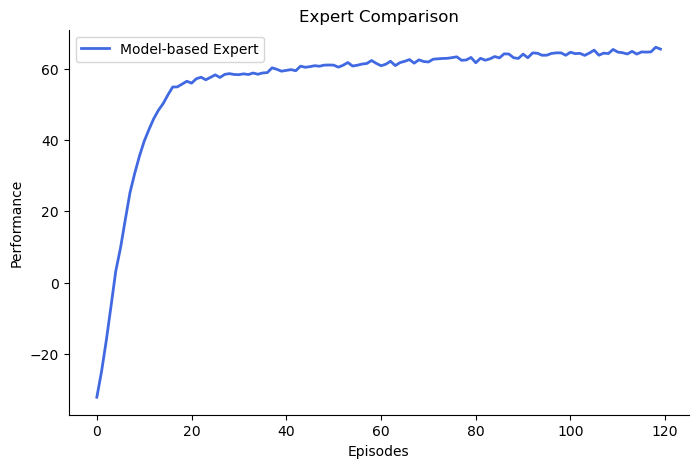

In [ ]:
# --- Plot expert performance ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.mean(mbased_expert_rewards, axis = 0), color = "royalblue", linewidth=2, label = "Model-based Expert")

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Episodes")
ax.set_ylabel("Performance")
plt.title("Expert Comparison")
plt.legend()

#fig.savefig(f'saved/figures/performance_expert_comparison.png')
plt.show()

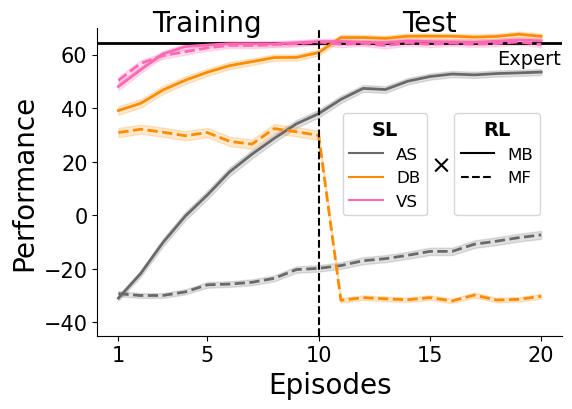

In [ ]:
# --- Plot performance of all agents ---
mbased_performance = [mbased_agent_rewards, mbased_dbias_rewards, mbased_vshaping_rewards]
mfree_performance = [mfree_agent_rewards, mfree_dbias_rewards, mfree_vshaping_rewards]

# Expert average performance for the episodes during training phase
expert_mean_perf = np.mean(mbased_expert_rewards[:, 100:110])

legend = exp # Set to 'None' to remove legend, otherwise exp defines legend placement
fig = all_models(mbased_performance, mfree_performance, 20, 0.5, ylabel="Performance", legend = legend, expert = expert_mean_perf)

# Save figure
fig.savefig(f'saved/figures/{exp}/performance_{exp}.svg', bbox_inches='tight')

In [ ]:
# --- Plot number of steps to reward ---
mbased_steps = [mbased_agent_steps, mbased_dbias_steps, mbased_vshaping_steps]
mfree_steps = [mfree_agent_steps, mfree_dbias_steps, mfree_vshaping_steps]

# Expert average steps for the episodes during training phase
expert_mean_steps = np.mean(mbased_expert_steps[:, 100:110])

all_models(mbased_steps, mfree_steps, 20, 0.5, ylabel="Steps to reward", expert = expert_mean_steps, legend = exp)

#### Indirect value transfer 
Compare value function of agents and expert in Exp. 1 (Baseline)

In [ ]:
# --- Compute correlation between expert and agent values ---
states = "all" # "all","visited" or "unvisited"

# Compute the Spearman correlation coefficient
spearman_mbased_agent = value_correlation(mbased_expert_value, mbased_expert_states, mbased_agent_value, mbased_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mbased_dbias = value_correlation(mbased_expert_value, mbased_expert_states, mbased_dbias_value, mbased_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mbased_vshaping = value_correlation(mbased_expert_value, mbased_expert_states,mbased_vshaping_value, mbased_vshaping_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)

spearman_mfree_agent = value_correlation(mbased_expert_value, mbased_expert_states, mfree_agent_value, mfree_agent_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mfree_dbias = value_correlation(mbased_expert_value, mbased_expert_states, mfree_dbias_value, mfree_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mfree_vshaping = value_correlation(mbased_expert_value, mbased_expert_states,mfree_vshaping_value, mfree_vshaping_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)

# Transform to z and back 
mean_mbased_agent, sem_mbased_agent = z_transform_intervals(spearman_mbased_agent, n_simulations)
mean_mbased_dbias, sem_mbased_dbias = z_transform_intervals(spearman_mbased_dbias, n_simulations)
mean_mbased_vshaping, sem_mbased_vshaping = z_transform_intervals(spearman_mbased_vshaping, n_simulations)

mean_mfree_agent, sem_mfree_agent = z_transform_intervals(spearman_mfree_agent, n_simulations)
mean_mfree_dbias, sem_mfree_dbias = z_transform_intervals(spearman_mfree_dbias, n_simulations)
mean_mfree_vshaping, sem_mfree_vshaping = z_transform_intervals(spearman_mfree_vshaping, n_simulations)


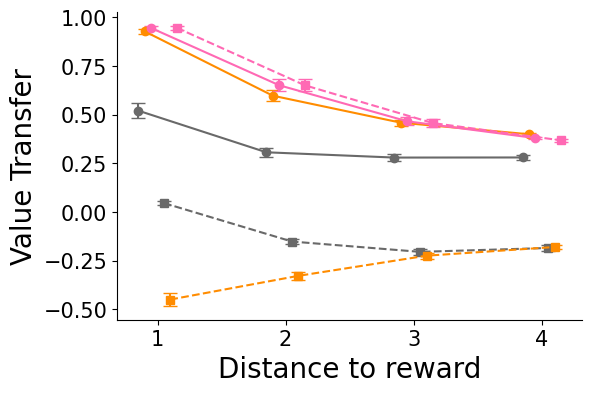

In [ ]:
# --- Plot value correlation ---
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))
linewidth = 1.5
offsets = [-0.15, -0.1, -0.05, 0.05, 0.1, 0.15]

ax.errorbar(
    x + offsets[0], mean_mbased_agent,
    yerr=sem_mbased_agent,
    fmt='o-', color="dimgray", linewidth=linewidth, label="Asocial Learning", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[1], mean_mbased_dbias,
    yerr=sem_mbased_dbias,
    fmt='o-', color="darkorange", linewidth=linewidth, label="Decision Bias", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[2], mean_mbased_vshaping,
    yerr=sem_mbased_vshaping,
    fmt='o-', color="hotpink", linewidth=linewidth, label="Value Shaping", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[3], mean_mfree_agent,
    yerr=sem_mfree_agent,
    fmt='s--', color="dimgray", linewidth=linewidth, label="Asocial Learning (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[4], mean_mfree_dbias,
    yerr=sem_mfree_dbias,
    fmt='s--', color="darkorange", linewidth=linewidth, label="Decision Bias (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[5], mean_mfree_vshaping,
    yerr=sem_mfree_vshaping,
    fmt='s--', color="hotpink", linewidth=linewidth, label="Value Shaping (MF)", capsize=5, capthick=1
)
 
# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Value Transfer", size = 20)
#plt.legend()

fig.savefig(f'saved/figures/{exp}/value_correlation_{exp}.svg', bbox_inches='tight')

#### Value accuracy
Compare value function of agents with true value function in Exp. 2 (~ Fig. 4b)

In [ ]:
# --- Compute true value function using the Bellman equation ---
n_episodes = 10
rewards_info_test = np.array(rewards_info_exp2)[:, -n_episodes:, :] 
true_q_values = compute_true_value_function(true_tms, rewards_info_test)

In [ ]:
# --- Compute correlation between true and agent values ---
states = "unvisited" # "all", "visited", "unvisited"

# Compute the Spearman correlation coefficient
spearman_mbased_agent = value_correlation(true_q_values, None, mbased_agent_value, mbased_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mbased_dbias = value_correlation(true_q_values, None, mbased_dbias_value, mbased_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mbased_vshaping = value_correlation(true_q_values, None, mbased_vshaping_value, mbased_vshaping_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)

spearman_mfree_agent = value_correlation(true_q_values, None, mfree_agent_value, mfree_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mfree_dbias = value_correlation(true_q_values, None, mfree_dbias_value, mfree_dbias_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)
spearman_mfree_vshaping = value_correlation(true_q_values, None, mfree_vshaping_value, mfree_vshaping_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)

spearman_mbased_expert = value_correlation(true_q_values, None, mbased_expert_value, mbased_expert_states, true_tms, reward_info_per_sim, n_simulations, max_d, states)

# Get mean and sem of the Spearman correlation
mean_mbased_agent, sem_mbased_agent = z_transform_intervals(spearman_mbased_agent, n_simulations)
mean_mbased_dbias, sem_mbased_dbias = z_transform_intervals(spearman_mbased_dbias, n_simulations)
mean_mbased_vshaping, sem_mbased_vshaping = z_transform_intervals(spearman_mbased_vshaping, n_simulations)

mean_mfree_agent, sem_mfree_agent = z_transform_intervals(spearman_mfree_agent, n_simulations)
mean_mfree_dbias, sem_mfree_dbias = z_transform_intervals(spearman_mfree_dbias, n_simulations)
mean_mfree_vshaping, sem_mfree_vshaping = z_transform_intervals(spearman_mfree_vshaping, n_simulations)

mean_mbased_expert, sem_mbased_expert = z_transform_intervals(spearman_mbased_expert, n_simulations)

In [ ]:
# --- Plot value correlation with true values ---
x = np.arange(1, max_d)
fig, ax = plt.subplots(figsize=(6, 4))
linewidth = 1.5
offsets = [-0.1, -0.05, 0, 0.05, 0.1, 0.15]  # Offsets for each point

ax.errorbar(
    x + offsets[0], mean_mbased_agent,
    yerr= sem_mbased_agent,
    fmt='o-', color="dimgray", linewidth=linewidth, label="Asocial Learning", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[1], mean_mbased_dbias,
    yerr= sem_mbased_dbias,
    fmt='o-', color="darkorange", linewidth=linewidth, label="Decision Bias", capsize=5, capthick=1
)

ax.errorbar(
    x, mean_mbased_vshaping,
    yerr= sem_mbased_vshaping,
    fmt='o-', color="hotpink", linewidth=linewidth, label="Value Shaping", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[3], mean_mfree_agent,
    yerr= sem_mfree_agent,  
    fmt='s--', color="dimgray", linewidth=linewidth, label="Asocial Learning (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[4], mean_mfree_dbias,
    yerr= sem_mfree_dbias,  
    fmt='s--', color="darkorange", linewidth=linewidth, label="Decision Bias (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[5], mean_mfree_vshaping,
    yerr= sem_mfree_vshaping,
    fmt='s--', color="hotpink", linewidth=linewidth, label="Value Shaping (MF)", capsize=5, capthick=1
)
 
# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

## Custom legend
#type_of_model = [
#    Line2D([0], [0], color = "black", linewidth=1.5, label = "MB" ),
#    Line2D([0], [0], color = "black", linewidth=1.5, linestyle='--' , label = "MF"),
#    ]
#
#
#social_strategy = [
#Line2D([0], [0], color = "dimgray", linewidth=1.5, label = "AS"),
#Line2D([0], [0], color = "darkorange", linewidth=1.5, label = "DB"),
#Line2D([0], [0], color = "hotpink", linewidth=1.5, label = "VS")
#    ]
#
#legend1 = ax.legend(handles=social_strategy, loc='upper left', bbox_to_anchor=(0.38, 1), fontsize = 12, frameon=False)
#ax.add_artist(legend1)  # Add the first legend to the axes
#legend2 = ax.legend(handles=type_of_model, loc='upper left', bbox_to_anchor=(0.50, 1), fontsize = 12, frameon=False)


ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Value accuracy", size = 20)
#plt.legend()

fig.savefig(f'saved/figures/{exp}/value_correlation_true_qvalues_{exp}.svg', bbox_inches='tight')
plt.show()

#### Indirect belief transfer
Compare expert's and agent's transition matrices in Exp. 1 (Baseline; ~ Fig. 3c)

In [ ]:
# --- Compute Pearson correlation between expert and agent TMs ---
all_states = True # Consider all states

# Only for model-based
mean_mbased_agent_tm, sem_mbased_agent_tm, mean_z_mbased_agent, sem_z_mbased_agent = tm_ztransform_distance(
    exp_tm, mbased_expert_states, agt_tm, mbased_agent_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

mean_mbased_dbias_tm, sem_mbased_dbias_tm, mean_z_mbased_dbias, sem_z_mbased_dbias = tm_ztransform_distance(
    exp_tm, mbased_expert_states, db_tm, mbased_dbias_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

mean_mbased_vshaping_tm, sem_mbased_vshaping_tm, mean_z_mbased_vshaping, sem_z_mbased_vshaping = tm_ztransform_distance(
    exp_tm, mbased_expert_states, vs_tm, mbased_vshaping_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

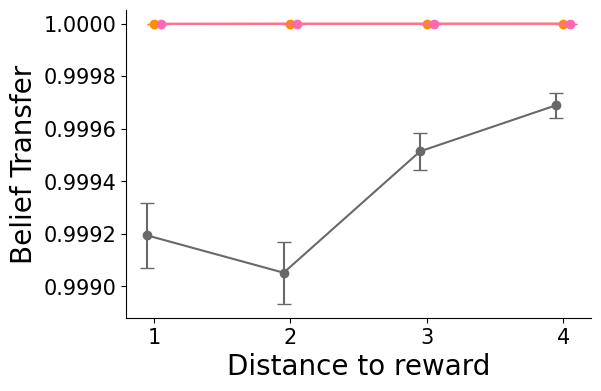

In [ ]:
# --- Plot indirect belief transfer ---
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))

offset = [-0.05, 0, 0.05] # Jitter to avoid overlap
x = np.arange(1, max_d)

ax.errorbar(
    x + offset[0], mean_mbased_agent_tm,
    yerr=sem_mbased_agent_tm,
    fmt='o-', color="dimgray", linewidth=1.5, label="Asocial Learning", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[1], mean_mbased_dbias_tm,
    yerr=sem_mbased_dbias_tm,
    fmt='o-', color="darkorange", linewidth=1.5, label="Decision Bias", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[2], mean_mbased_vshaping_tm,
    yerr=sem_mbased_vshaping_tm,
    fmt='o-', color="hotpink", linewidth=1.5, label="Value Shaping", capsize=5, capthick=1
)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Belief Transfer", fontsize = 20)
#plt.legend()
fig.savefig(f'saved/figures/{exp}/tm_correlation_{exp}.svg', bbox_inches='tight')

In [ ]:
# --- Normalize TM correlation using asocial learner as baseline ---
# --> How much "extra" belief transfer occurs? 
norm_mean_dbias, norm_sem_dbias = normalize_tm_correlation(
    mean_mbased_dbias_tm, sem_mbased_dbias_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

norm_mean_vshaping, norm_sem_vshaping = normalize_tm_correlation(
    mean_mbased_vshaping_tm, sem_mbased_vshaping_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

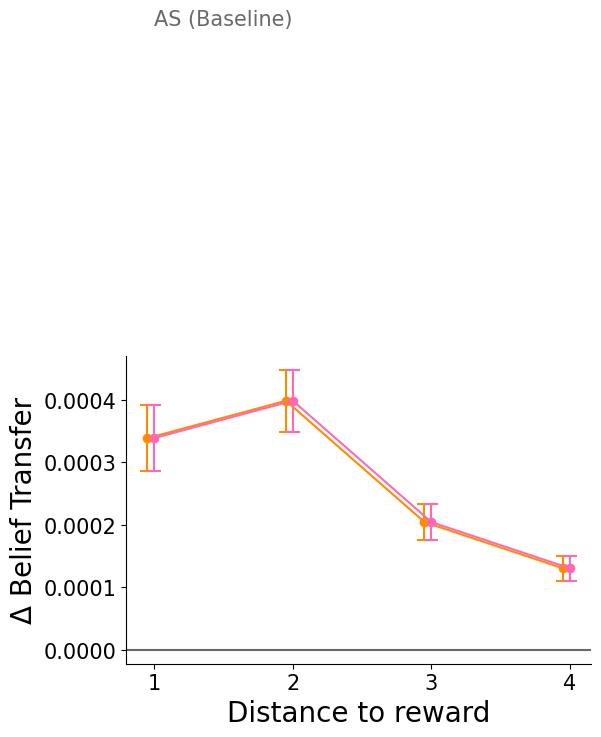

In [ ]:
# --- Plot normalized belief transfer ---
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))
offset = [-0.05, 0, 0.05] # Jitter to avoid overlap


ax.errorbar(
    x + offset[0], norm_mean_dbias,
    yerr=norm_sem_dbias,
    fmt='o-', color="darkorange", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1.5
)
ax.errorbar(
    x + offset[1], norm_mean_vshaping,
    yerr=norm_sem_vshaping,
    fmt='o-', color="hotpink", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1.5
)
ax.axhline(0, color='dimgray', label='Baseline (AS)', linewidth=1.5)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Δ Belief Transfer", fontsize = 20)
# Add label directly above the line
ax.text(1, 0.001, 'AS (Baseline)', color='dimgray', fontsize=15)

#fig.savefig(f'saved/figures/{exp}/tm_correlation_{exp}_baseline.svg', bbox_inches='tight')


#### Robustness of beliefs
Compare agent's TM in Exp. 1 (baseline; original start locations) with agent's TM in Exp. 3 (novel start locations; ~ Fig. 4d) 

In [ ]:
# --- Load agent data for baseline ---
exp = 'baseline'  

# MB
mbased_expert_rewards_base, mbased_expert_steps_base, mbased_expert_value_base, mbased_expert_states_base, mbased_expert_actions_base, mbased_expert_model_base = load_data(f'saved/baseline/mbased_expert_baseline')
mbased_agent_rewards_base, mbased_agent_steps_base, mbased_agent_value_base, mbased_agent_states_base, mbased_agent_actions_base, mbased_agent_model_base = load_data(f'saved/{exp}/mbased_agent_{exp}')
mbased_vshaping_rewards_base, mbased_vshaping_steps_base, mbased_vshaping_value_base, mbased_vshaping_states_base, mbased_vshaping_actions_base = load_data(f'saved/{exp}/mbased_vshaping_{exp}')
mbased_dbias_rewards_base, mbased_dbias_steps_base, mbased_dbias_value_base, mbased_dbias_states_base, mbased_dbias_actions_base = load_data(f'saved/{exp}/mbased_dbias_{exp}')


# Load tm for model-based agents
etm_load = np.load('saved/baseline/tmss/mbased_expert_tm.npz')
exp_tm_based = [etm_load[f'arr_{i}'] for i in range(len(etm_load.files))]

atm_load = np.load(f'saved/{exp}/tmss/mbased_agent_tm.npz')
agt_tm_based = [atm_load[f'arr_{i}'] for i in range(len(atm_load.files))]

vstm_load = np.load(f'saved/{exp}/tmss/vshaping_tm.npz')
vs_tm_based = [vstm_load[f'arr_{i}'] for i in range(len(vstm_load.files))]

dbtm_load = np.load(f'saved/{exp}/tmss/dbias_tm.npz')
db_tm_based = [dbtm_load[f'arr_{i}'] for i in range(len(dbtm_load.files))]

In [ ]:
# --- Compute TM similarity over distances for new experiment and baseline ---
all_states = True # Consider all states


r_new_agent = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, agt_tm, mbased_agent_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_new_dbias = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, db_tm, mbased_dbias_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_new_vshaping = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, vs_tm, mbased_vshaping_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

r_base_agent = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, agt_tm_based, mbased_agent_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_base_dbias = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, db_tm_based, mbased_dbias_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_base_vshaping = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, vs_tm_based, mbased_vshaping_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

In [ ]:
# --- Plot histogram of TM similarity for exp. 3 and baseline ---

# Compute residuals
residual_agent = r_new_agent - r_base_agent
residual_dbias = r_new_dbias - r_base_dbias
residual_vshaping = r_new_vshaping - r_base_vshaping

# Helper function to compute binned means and confidence intervals
def get_binned_stats(x, y, n_bins=10):
    df = pd.DataFrame({'x': x, 'y': y})
    df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')
    
    summary = df.groupby('bin', observed=True).agg(
        x_mean=('x', 'mean'),
        y_mean=('y', 'mean'),
        y_std=('y', 'std'),
        count=('y', 'count')
    ).reset_index()
    
    summary['y_ci'] = 1.96 * (summary['y_std'] / np.sqrt(summary['count']))
    return summary

## Plot histogram of residuals (main plot)
fig, ax = plt.subplots(figsize=(7, 5))

bins_hist = 15
ax.hist(residual_agent, bins=bins_hist, alpha=0.5, color='dimgray', label="Asocial Learning")
ax.hist(residual_dbias, bins=bins_hist, alpha=0.5, color='darkorange', label="Decision Bias")
ax.hist(residual_vshaping, bins=bins_hist, alpha=0.5, color='hotpink', label="Value Shaping")

ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel(r'Belief stability ($\Delta$ transfer)', fontsize=22)
ax.set_ylabel('# Simulations', fontsize=22)


# Main axes style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=17)


## Plot binned regression (inset)
axins = inset_axes(ax, width="60%", height="60%",
                   bbox_to_anchor=(0.16, 0.3, 0.6, 0.6),
                   bbox_transform=ax.transAxes,
                   loc='upper left')

groups = [
    (r_base_agent, r_new_agent, "dimgray"),
    (r_base_dbias, r_new_dbias, "darkorange"),
    (r_base_vshaping, r_new_vshaping, "hotpink")
]

n_bins = 8 
for x_data, y_data, color in groups:
    stats_df = get_binned_stats(x_data, y_data, n_bins=n_bins)
    axins.errorbar(
        stats_df['x_mean'], stats_df['y_mean'], 
        yerr=stats_df['y_ci'], 
        fmt='o', color=color, markersize=4,
        capsize=2, capthick=1, elinewidth=1
    )

# Calculate limits for the inset
all_x = np.concatenate([r_base_agent, r_base_dbias, r_base_vshaping])
all_y = np.concatenate([r_new_agent, r_new_dbias, r_new_vshaping])
data_min = min(all_x.min(), all_y.min())
data_max = max(all_x.max(), all_y.max())
padding = (data_max - data_min) * 0.05

plot_min = 0.991
plot_max = data_max + padding

axins.set_xlim(plot_min, plot_max)
axins.set_ylim(plot_min, plot_max)

# Identity line for inset
axins.plot([plot_min, plot_max], [plot_min, plot_max], 
           linestyle="--", color="black", linewidth=1, zorder=0)

# Inset labels and style
axins.set_title("Belief transfer", size=16)
axins.set_xlabel("Baseline", size=14)
axins.set_ylabel("New start states", size=14)
axins.tick_params(axis='both', labelsize=12)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

# Save/Show
#fig.savefig('saved/figures/exp3/reversed_robustness_summary.svg', bbox_inches='tight')
plt.show()